In [4]:
# Install required libraries
!pip install yfinance pandas matplotlib numpy

In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Plot style
plt.style.use('default')

In [10]:
# Load your local Tesla CSV data (no rate limit issues!)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set plot style
plt.style.use('default')

# Load the CSV file (use the EXACT name of your file!)
df = pd.read_csv("tesla_3years.csv")

# Convert Date column to datetime (critical for plotting dates)
df['Date'] = pd.to_datetime(df['Date'])

# Check the loaded data
print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

# Calculate daily return
df['Daily_Return'] = df['Close'].pct_change()
df = df.dropna(subset=['Daily_Return'])

# Show cleaned data
df.head()

Dataset shape: (782, 6)

Missing values:
 Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


,Date,Open,High,Low,Close,Volume,Daily_Return
1,2022-01-04,198.926185,203.978761,196.021794,197.481138,74748301,-0.004471
2,2022-01-05,197.965062,207.531463,189.340473,200.470683,74377124,0.015138
3,2022-01-06,199.614591,203.326625,196.097872,201.773715,58603793,0.006500
4,2022-01-07,201.908772,209.032513,199.186858,205.168535,81109225,0.016825
5,2022-01-10,203.968027,208.705226,202.512857,205.238444,73644402,0.000341


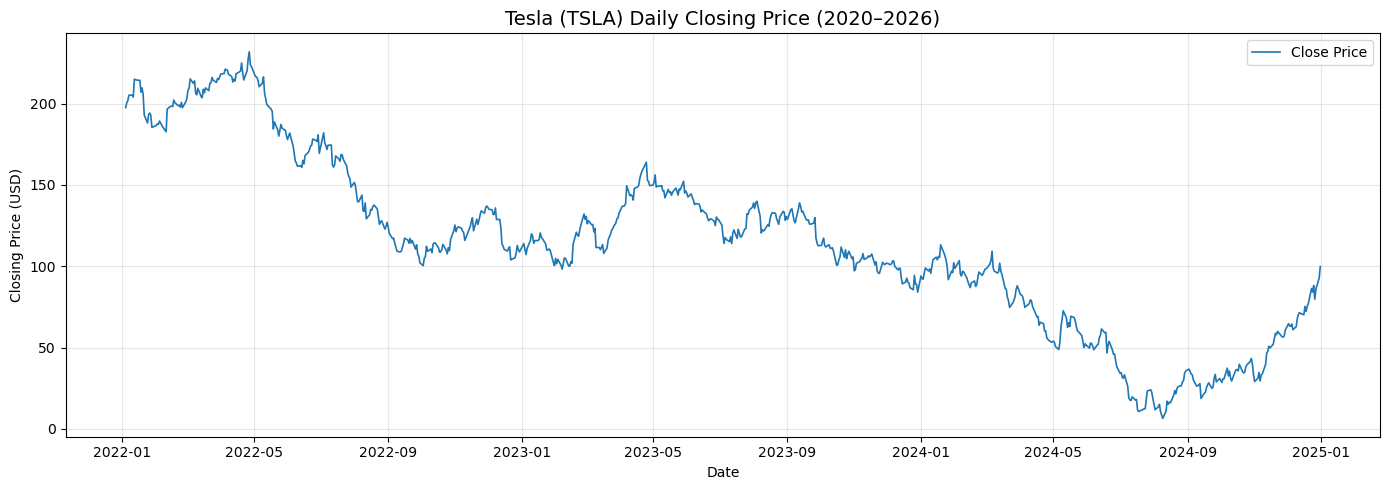

In [11]:
# Plot 1: Closing Price Trend
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close'], linewidth=1.2, color='#1f77b4', label='Close Price')
plt.title('Tesla (TSLA) Daily Closing Price (2020–2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

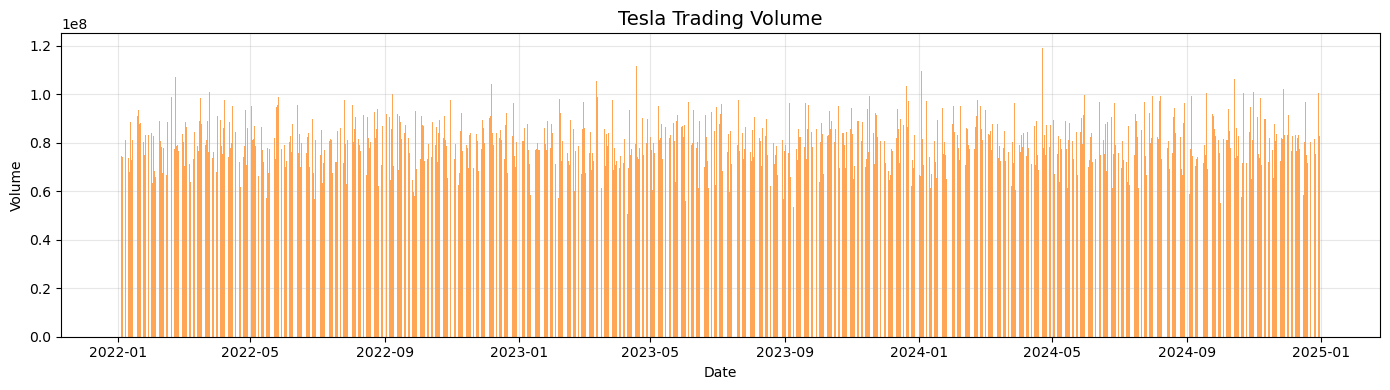

In [12]:
# Plot 2: Trading Volume
plt.figure(figsize=(14, 4))
plt.bar(df['Date'], df['Volume'], color='#ff7f0e', alpha=0.7)
plt.title('Tesla Trading Volume', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

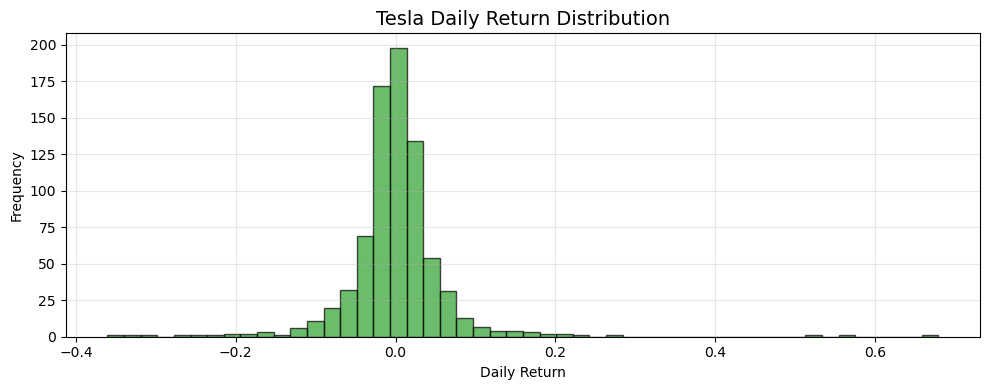

In [13]:
# Plot 3: Daily Return Distribution
plt.figure(figsize=(10, 4))
plt.hist(df['Daily_Return'], bins=50, color='#2ca02c', edgecolor='black', alpha=0.7)
plt.title('Tesla Daily Return Distribution', fontsize=14)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


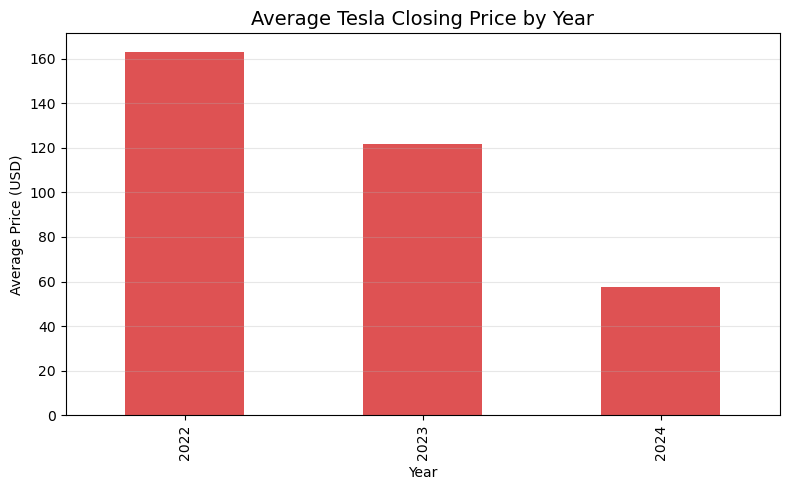

In [14]:
# Plot 4: Average Close Price by Year
df['Year'] = df['Date'].dt.year
year_avg = df.groupby('Year')['Close'].mean()

plt.figure(figsize=(8, 5))
year_avg.plot(kind='bar', color='#d62728', alpha=0.8)
plt.title('Average Tesla Closing Price by Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Price (USD)')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [ ]:
# Key Statistics
print("===== Key Statistics =====")
print("Mean Daily Return:", round(df['Daily_Return'].mean(), 6))
print("Daily Return Std:", round(df['Daily_Return'].std(), 6))
print("Max Daily Return:", round(df['Daily_Return'].max(), 4))
print("Min Daily Return:", round(df['Daily_Return'].min(), 4))
print("Total Return Period:", round((df['Close'].iloc[-1] / df['Close'].iloc[0] - 1), 4))